# EDA: Dataset de Risco de Lesão no Futebol

Este notebook realiza análise exploratória de dados no dataset pré processado de risco de lesão no futebol.

**Objetivos:**
- Carregar e inspecionar o dataset pré processado
- Analisar tipos de dados, dimensões e valores ausentes
- Visualizar a distribuição dos rótulos de risco
- Explorar indicadores-chave de saúde por nível de risco
- Validar qualidade da mesclagem e integridade dos dados

In [1]:
from pathlib import Path
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.insert(0, str(Path.cwd().parent / "src"))
from preprocessing import load_and_preprocess
from risk_score import engineer_risk_label, get_risk_statistics

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
print("Imports e configurações concluídas")

Imports e configurações concluídas


## 1. Carregar e Pré processar Dados

In [2]:
print("Carregando dados de data/pre/, data/post/, data/match/...")
data_dir = Path.cwd().parent
df = load_and_preprocess(data_dir)
print(f"Dados carregados com sucesso")
print(f"  - Dimensão: {df.shape}")
print(f"  - IDs das partidas: {sorted(df['match_id'].unique())}")

Carregando dados de data/pre/, data/post/, data/match/...
Dados carregados com sucesso
  - Dimensão: (28, 57)
  - IDs das partidas: [np.int64(1), np.int64(2), np.int64(3)]


## 2. Gerar Rótulos de Risco

In [3]:
df = engineer_risk_label(df)
risk_stats = get_risk_statistics(df)
print("Rótulos de risco gerados")
print(f"\nDistribuição dos rótulos de risco:")
for label, count in risk_stats['counts'].items():
    pct = risk_stats['percentages'][label]
    print(f"  {label:8s}: {count:2d} ({pct:5.1f}%)")

Rótulos de risco gerados

Distribuição dos rótulos de risco:
  Medium  : 16 ( 57.1%)
  High    :  7 ( 25.0%)
  Low     :  5 ( 17.9%)


## 3. Visão Geral do Dataset

In [4]:
print("Informações do dataset:")
print(f"  Total de amostras: {len(df)}")
print(f"  Total de colunas: {len(df.columns)}")
print(f"\nTipos de dados:")
dtype_counts = df.dtypes.value_counts()

for dtype, count in dtype_counts.items():
    print(f"  {str(dtype):15s}: {count:2d}")
print(f"\nAtletas únicos: {df['nickname'].nunique()}")
print(f"IDs das partidas: {sorted(df['match_id'].unique())}")

Informações do dataset:
  Total de amostras: 28
  Total de colunas: 59

Tipos de dados:
  float64        : 33
  int64          : 15
  str            :  9
  object         :  2

Atletas únicos: 15
IDs das partidas: [np.int64(1), np.int64(2), np.int64(3)]


## 4. Análise de Valores Ausentes

In [5]:
missing_info = df.isnull().sum()
missing_pct = (missing_info / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Column': missing_info.index,
    'Missing Count': missing_info.values,
    'Missing %': missing_pct.values
}).sort_values('Missing %', ascending=False)
missing_with_values = missing_df[missing_df['Missing %'] > 0]
if len(missing_with_values) > 0:
    print(f"Colunas com valores ausentes ({len(missing_with_values)} no total):")
    print(missing_with_values.head(15).to_string(index=False))
else:
    print("✓ Nenhum valor ausente encontrado")

Colunas com valores ausentes (6 no total):
            Column  Missing Count  Missing %
adequate_hydration             28     100.00
    penalty_missed             28     100.00
    penalty_scored             28     100.00
   penalty_against             28     100.00
      penalty_goal             28     100.00
         timestamp              9      32.14


## 5. Distribuição dos Rótulos de Risco

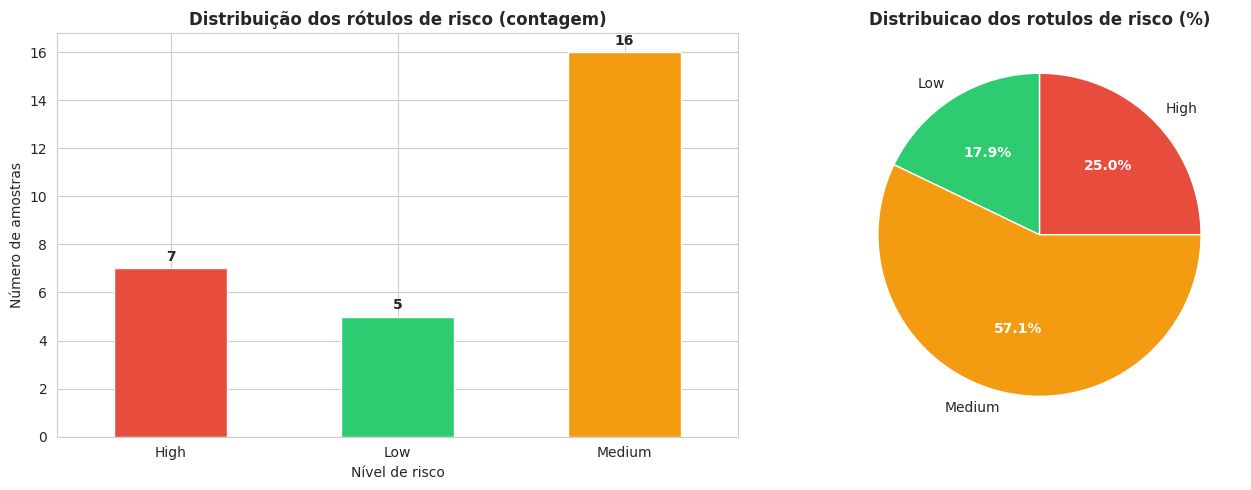

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
risk_counts = df['risk_label'].value_counts().sort_index()
colors = {'Low': '#2ecc71', 'Medium': '#f39c12', 'High': '#e74c3c'}
ax = axes[0]
risk_counts.plot(kind='bar', ax=ax, color=[colors.get(label, '#95a5a6') for label in risk_counts.index])
ax.set_title('Distribuição dos rótulos de risco (contagem)', fontsize=12, fontweight='bold')
ax.set_xlabel('Nível de risco')
ax.set_ylabel('Número de amostras')
ax.set_xticklabels(risk_counts.index, rotation=0)
for i, v in enumerate(risk_counts.values):
    ax.text(i, v + 0.3, str(v), ha='center', fontweight='bold')
ax = axes[1]
wedges, texts, autotexts = ax.pie(risk_counts.values, labels=risk_counts.index, autopct='%1.1f%%',
                                     colors=[colors.get(label, '#95a5a6') for label in risk_counts.index])
ax.set_title('Distribuicao dos rotulos de risco (%)', fontsize=12, fontweight='bold')
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
plt.tight_layout()
plt.show()

## 6. Indicadores-Chave de Saúde por Nível de Risco

In [7]:
health_indicators = [
    ('sleep_hours', 'Horas de sono'),
    ('sleep_quality', 'Qualidade do sono'),
    ('rpe', 'RPE (Esforco percebido)'),
    ('fatigue_level', 'Nível de fadiga'),
    ('stress_level', 'Nível de estresse'),
]
print("Principais Indicadores de Saúde por Nível de Risco")
for col, label in health_indicators:
    if col in df.columns:
        print(f"{label}:")
        summary = df.groupby('risk_label')[col].agg(['count', 'mean', 'std', 'min', 'max']).round(2)
        print(summary)
        print()

Principais Indicadores de Saúde por Nível de Risco
Horas de sono:
            count  mean   std  min  max
risk_label                             
High            7  6.86  0.69  6.0  8.0
Low             5  6.80  0.45  6.0  7.0
Medium         16  6.75  0.77  5.0  8.0

Qualidade do sono:
            count  mean   std  min  max
risk_label                             
High            7  2.43  0.53  2.0  3.0
Low             5  2.60  0.55  2.0  3.0
Medium         16  2.38  0.50  2.0  3.0

RPE (Esforco percebido):
            count  mean   std  min  max
risk_label                             
High            7  9.00  1.00    8   10
Low             5  7.60  0.89    7    9
Medium         16  8.12  0.72    7    9

Nível de fadiga:
            count  mean   std  min  max
risk_label                             
High            7  8.86  1.07    7   10
Low             5  4.00  1.87    2    6
Medium         16  7.94  1.44    4   10

Nível de estresse:
            count  mean   std  min  max
risk_label

## 7. Visualizar Indicadores-Chave por Nível de Risco

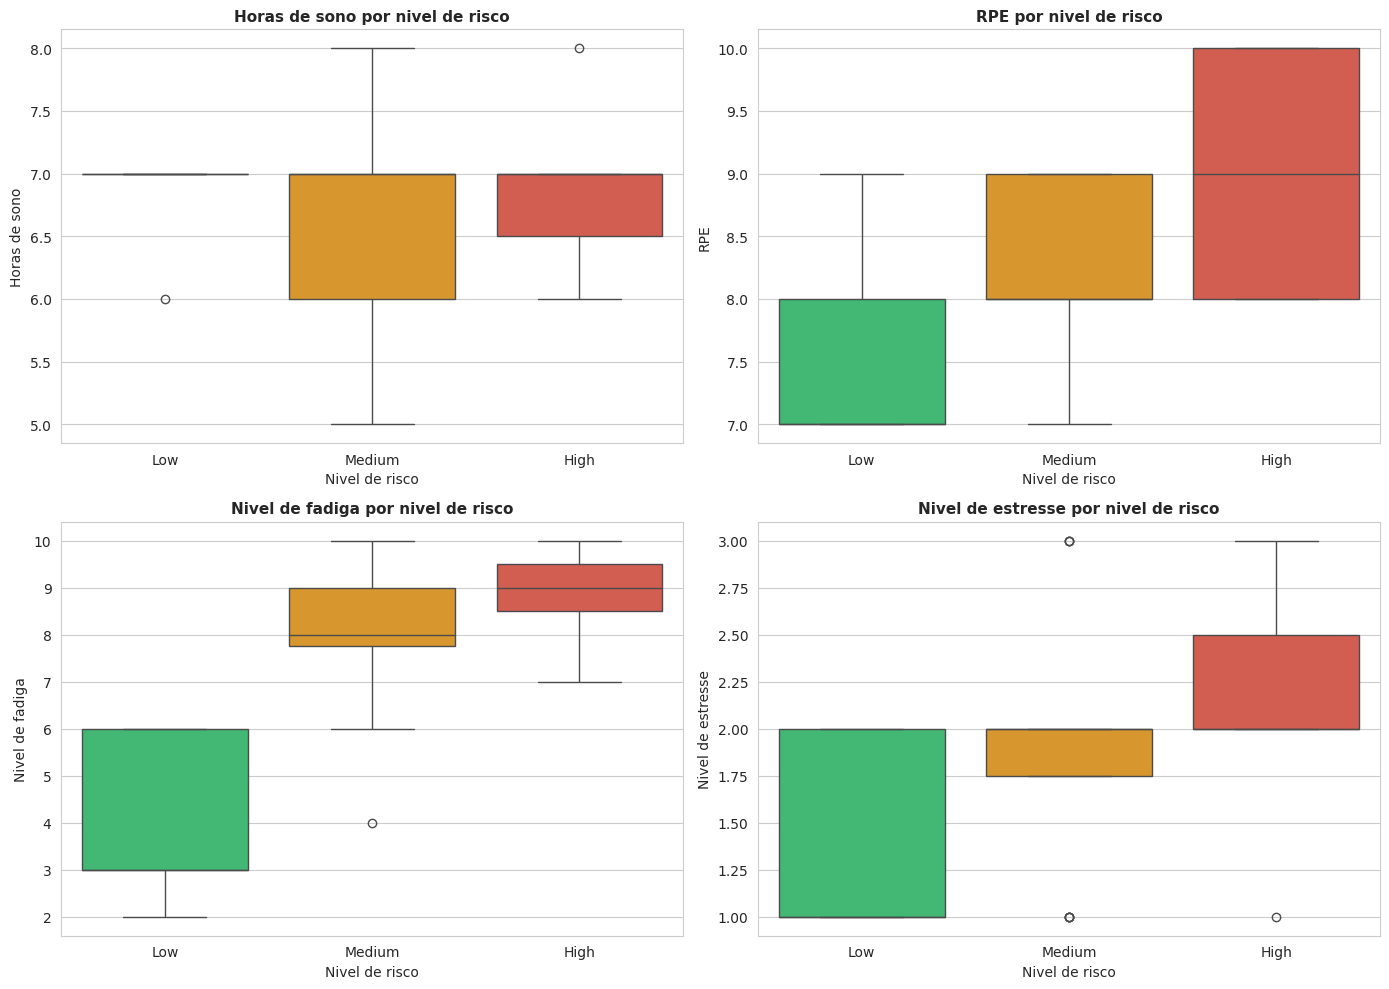

In [8]:
indicators_to_plot = [('sleep_hours', 'Horas de sono'), ('rpe', 'RPE'), ('fatigue_level', 'Nivel de fadiga'), ('stress_level', 'Nivel de estresse')]
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
risk_order = ['Low', 'Medium', 'High']
colors_palette = ['#2ecc71', '#f39c12', '#e74c3c']
for idx, (col, label) in enumerate(indicators_to_plot):
    if col in df.columns:
        ax = axes[idx]
        sns.boxplot(
            data=df,
            x='risk_label',
            y=col,
            hue='risk_label',
            order=risk_order,
            hue_order=risk_order,
            palette=colors_palette,
            legend=False,
            ax=ax,
        )
        ax.set_title(f"{label} por nivel de risco", fontsize=11, fontweight='bold')
        ax.set_xlabel('Nivel de risco')
        ax.set_ylabel(label)
plt.tight_layout()
plt.show()

## 8. Distribuição do Score de Risco

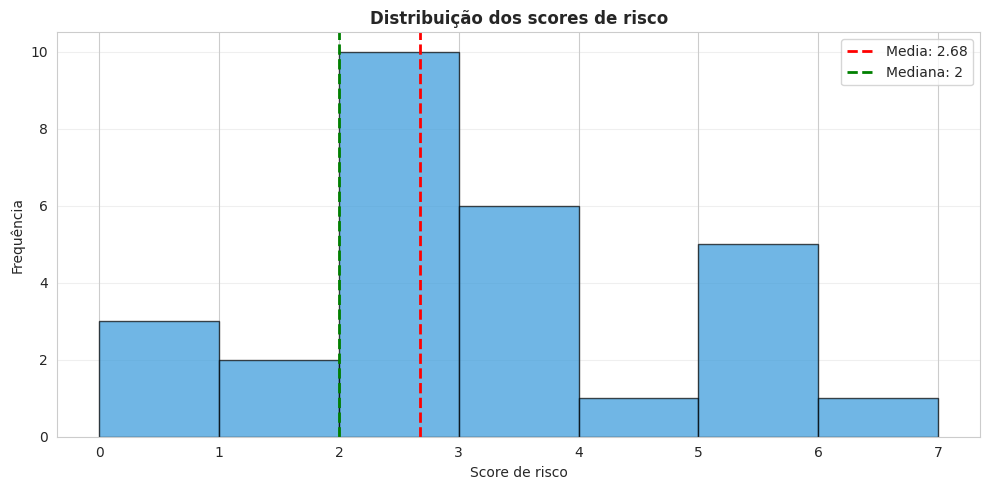


Resumo do score de risco:
  Min: 0
  Media: 2.68
  Mediana: 2
  Max: 6


In [9]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df['risk_score'], bins=range(0, int(df['risk_score'].max()) + 2), edgecolor='black', alpha=0.7, color='#3498db')
ax.axvline(df['risk_score'].mean(), color='red', linestyle='--', linewidth=2, label=f'Media: {df["risk_score"].mean():.2f}')
ax.axvline(df['risk_score'].median(), color='green', linestyle='--', linewidth=2, label=f'Mediana: {df["risk_score"].median():.0f}')
ax.set_title('Distribuição dos scores de risco', fontsize=12, fontweight='bold')
ax.set_xlabel('Score de risco')
ax.set_ylabel('Frequência')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()
print(f"\nResumo do score de risco:")
print(f"  Min: {df['risk_score'].min()}")
print(f"  Media: {df['risk_score'].mean():.2f}")
print(f"  Mediana: {df['risk_score'].median():.0f}")
print(f"  Max: {df['risk_score'].max()}")

## 9. Conclusões

In [10]:
print("Conclusões da EDA")
print(f"{len(df)} amostras de {df['nickname'].nunique()} atletas em {df['match_id'].nunique()} partidas")
print(f"Distribuição de risco: {risk_stats['percentages']}")
print(f"Pronto para a fase de Feature Engineering")

Conclusões da EDA
28 amostras de 15 atletas em 3 partidas
Distribuição de risco: {'Medium': 57.14, 'High': 25.0, 'Low': 17.86}
Pronto para a fase de Feature Engineering
